# 02 - Trực quan hóa dữ liệu

Notebook này tạo các biểu đồ quan trọng: histogram, boxplot, scatter plot và heatmap để nhìn quan hệ giữa `lwage` và các biến đầu vào.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    for base in candidates:
        if (base / "data" / "wage_model.csv").exists():
            return base
        nested = base / "Machine Learning"
        if (nested / "data" / "wage_model.csv").exists():
            return nested
    raise FileNotFoundError("Không tìm thấy data/wage_model.csv. Hãy mở notebook trong folder Machine Learning.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
RESULT_DIR = OUTPUT_DIR / "model_results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

eda_df = pd.read_csv(DATA_DIR / "wage_eda.csv")
model_df = pd.read_csv(DATA_DIR / "wage_model.csv")

print("Project root found.")
print("EDA data:", eda_df.shape)
print("Model data:", model_df.shape)


Project root found.
EDA data: (3010, 30)
Model data: (3010, 38)


## 2.1 Histogram và boxplot của `lwage`


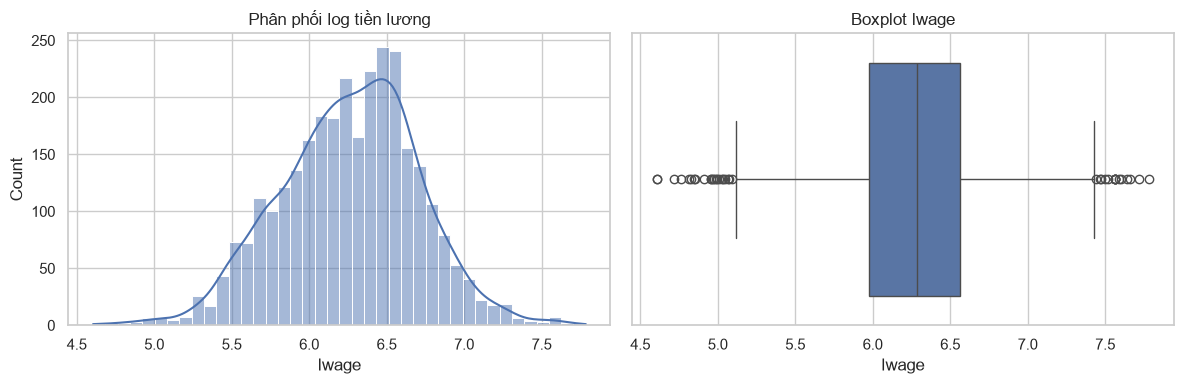

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(eda_df["lwage"], kde=True, ax=axes[0])
axes[0].set_title("Phân phối log tiền lương")
axes[0].set_xlabel("lwage")

sns.boxplot(x=eda_df["lwage"], ax=axes[1])
axes[1].set_title("Boxplot lwage")
axes[1].set_xlabel("lwage")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_lwage_hist_boxplot.png", dpi=200)
plt.show()


## 2.2 Boxplot `lwage` theo nhóm


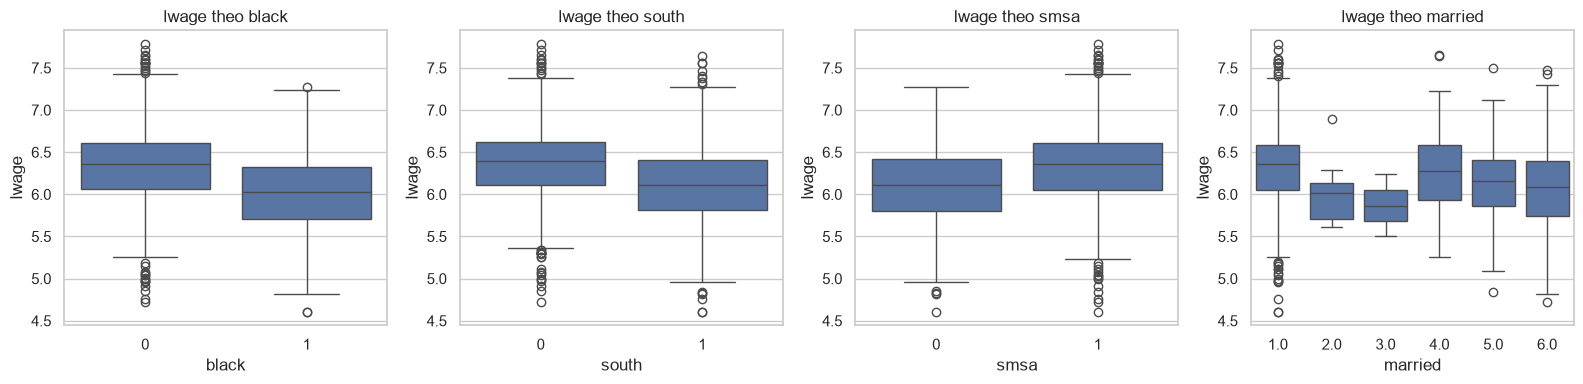

In [3]:
group_cols = ["black", "south", "smsa", "married"]
group_cols = [col for col in group_cols if col in eda_df.columns]

fig, axes = plt.subplots(1, len(group_cols), figsize=(4 * len(group_cols), 4))
if len(group_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, group_cols):
    sns.boxplot(data=eda_df, x=col, y="lwage", ax=ax)
    ax.set_title(f"lwage theo {col}")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_lwage_by_groups.png", dpi=200)
plt.show()


## 2.3 Scatter plot với đường xu hướng


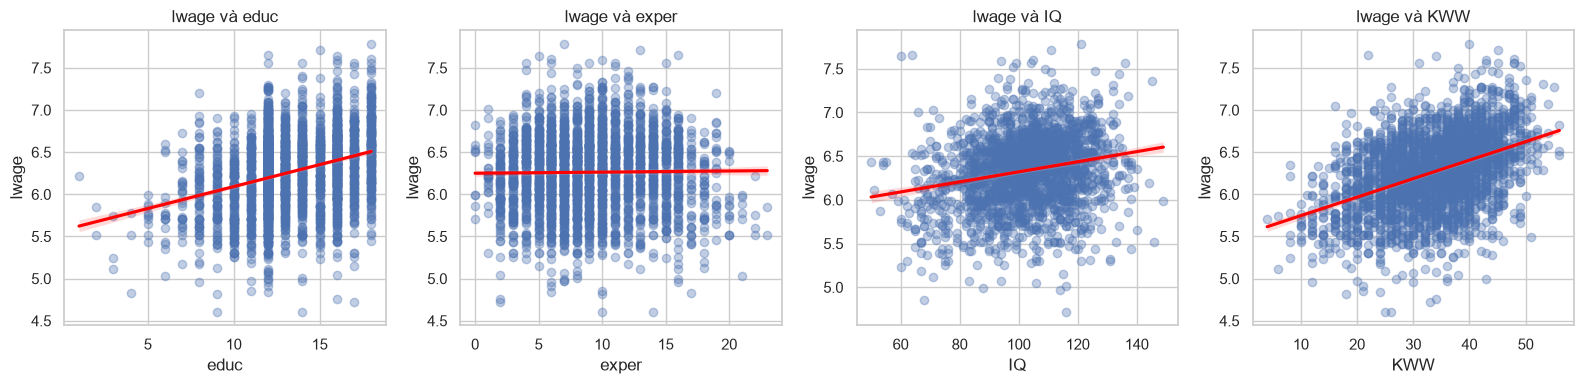

In [4]:
scatter_cols = ["educ", "exper", "IQ", "KWW"]
scatter_cols = [col for col in scatter_cols if col in eda_df.columns]

fig, axes = plt.subplots(1, len(scatter_cols), figsize=(4 * len(scatter_cols), 4))
if len(scatter_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, scatter_cols):
    sns.regplot(data=eda_df, x=col, y="lwage", scatter_kws={"alpha": 0.35}, line_kws={"color": "red"}, ax=ax)
    ax.set_title(f"lwage và {col}")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_scatter_lwage_predictors.png", dpi=200)
plt.show()


## 2.4 Heatmap tương quan mở rộng


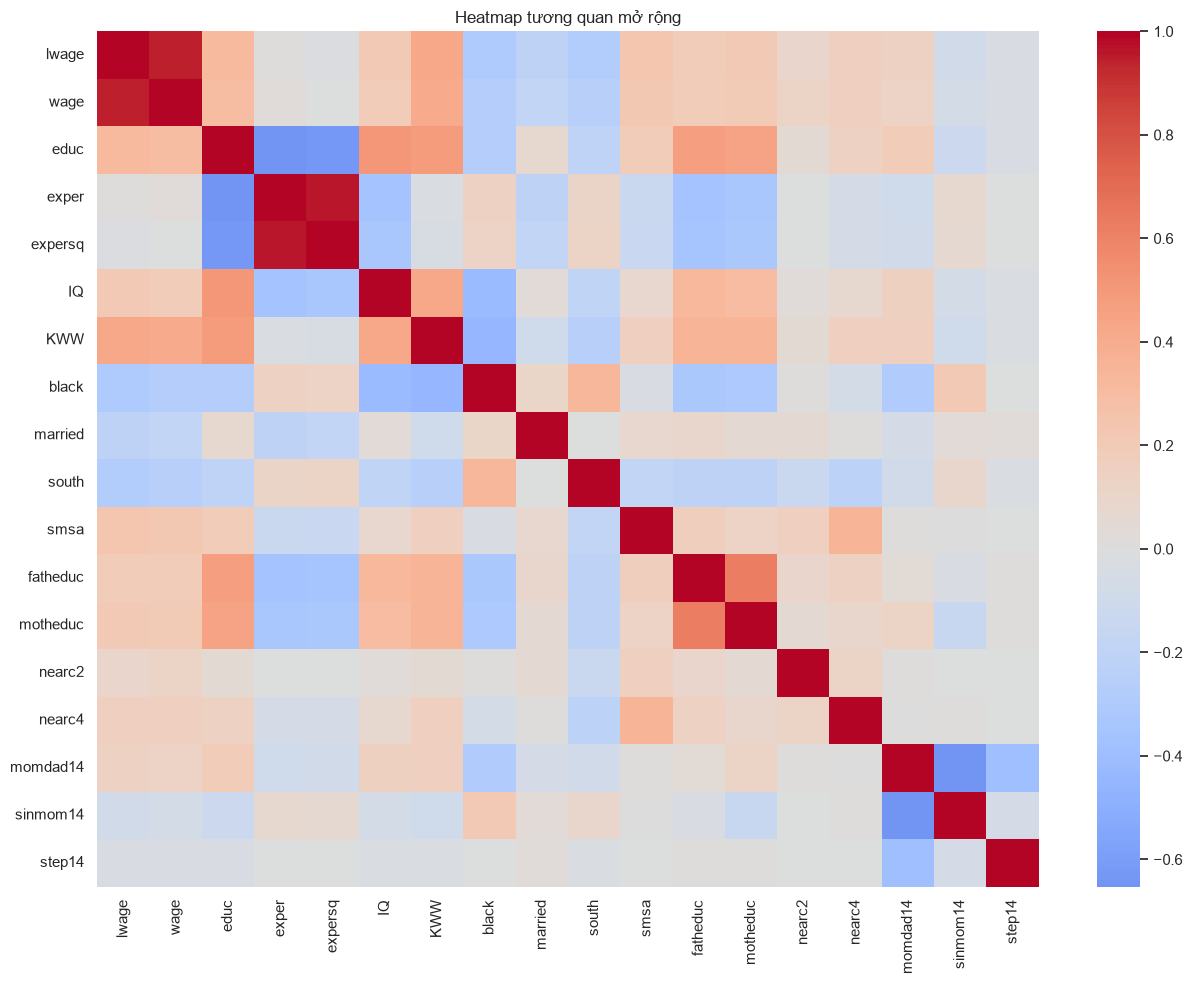

In [5]:
numeric_cols = eda_df.select_dtypes(include=np.number).columns.tolist()
selected_corr_cols = [col for col in numeric_cols if col in [
    "lwage", "wage", "educ", "exper", "expersq", "IQ", "KWW",
    "black", "married", "south", "smsa", "fatheduc", "motheduc",
    "nearc2", "nearc4", "momdad14", "sinmom14", "step14",
]]

plt.figure(figsize=(13, 10))
sns.heatmap(eda_df[selected_corr_cols].corr(), cmap="coolwarm", center=0, fmt=".2f")
plt.title("Heatmap tương quan mở rộng")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_extended_heatmap.png", dpi=200)
plt.show()


## Nhận xét ngắn

Các biểu đồ giúp kiểm tra phân phối, ngoại lệ, khác biệt theo nhóm và xu hướng giữa `lwage` với học vấn, kinh nghiệm, IQ/KWW trước khi đi vào mô hình.
